# 1. Setup Paths

In [3]:
import os
import tensorflow as tf

In [4]:
CUSTOM_MODEL_NAME = 'my_ssd_mobnet' 
PRETRAINED_MODEL_NAME = 'ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8'
PRETRAINED_MODEL_URL = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz'
TF_RECORD_SCRIPT_NAME = 'generate_tfrecord.py'
LABEL_MAP_NAME = 'label_map.pbtxt'

In [5]:
paths = {
    'WORKSPACE_PATH': os.path.join('Tensorflow', 'workspace'),
    'SCRIPTS_PATH': os.path.join('Tensorflow','scripts'),
    'APIMODEL_PATH': os.path.join('Tensorflow','models'),
    'ANNOTATION_PATH': os.path.join('Tensorflow', 'workspace','annotations'),
    'IMAGE_PATH': os.path.join('Tensorflow', 'workspace','images'),
    'MODEL_PATH': os.path.join('Tensorflow', 'workspace','models'),
    'PRETRAINED_MODEL_PATH': os.path.join('Tensorflow', 'workspace','pre-trained-models'),
    'CHECKPOINT_PATH': os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME), 
    'OUTPUT_PATH': os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'export'), 
    'TFJS_PATH':os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'tfjsexport'), 
    'TFLITE_PATH':os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'tfliteexport'), 
    'PROTOC_PATH':os.path.join('Tensorflow','protoc')
 }

In [6]:
files = {
    'PIPELINE_CONFIG':os.path.join('Tensorflow', 'workspace','models', CUSTOM_MODEL_NAME, 'pipeline.config'),
    'TF_RECORD_SCRIPT': os.path.join(paths['SCRIPTS_PATH'], TF_RECORD_SCRIPT_NAME), 
    'LABELMAP': os.path.join(paths['ANNOTATION_PATH'], LABEL_MAP_NAME)
}

In [7]:
for path in paths.values():
    if not os.path.exists(path):
        if os.name == 'posix':
            !mkdir -p {path}
        if os.name == 'nt':
            !mkdir {path}

# 2. Create Label Map

In [7]:
labels = [{'name':'10_guy', 'id':1}, {'name':'angry_advice_mallard', 'id':2}, {'name':'afraid_to_ask_andy', 'id':3}, {'name':'archer', 'id':4},{'name':'awkward_moment_sealion', 'id':5}, {'name':'baby_insanity_wolf', 'id':6}, {'name':'bad_luck_brain', 'id':7}, {'name':'birth_control_effectiveness', 'id':8}, {'name':'blue_button', 'id':9}, {'name':'boardroom_meeting_suggestion', 'id':10}, {'name':'but_thats_none_of_my_business', 'id':11}, {'name':'car_salesman', 'id':12}, {'name':'change_my_mind', 'id':13},{'name':'coma_patient', 'id':14},{'name':'math_lady', 'id':15},{'name':'advice_mallard', 'id':16},{'name':'chopper_argument', 'id':17},{'name':'dwarf', 'id':18}]


with open(files['LABELMAP'], 'w') as f:
    for label in labels:
        f.write('item { \n')
        f.write('\tname:\'{}\'\n'.format(label['name']))
        f.write('\tid:{}\n'.format(label['id']))
        f.write('}\n')

# 3. Create TF records

In [10]:
!pip install tensorflow

In [ ]:
# OPTIONAL IF RUNNING ON COLAB
ARCHIVE_FILES = os.path.join(paths['IMAGE_PATH'], 'archive.tar.gz')
if os.path.exists(ARCHIVE_FILES):
  !tar -zxvf {ARCHIVE_FILES}

In [11]:
if not os.path.exists(files['TF_RECORD_SCRIPT']):
    !git clone https://github.com/nicknochnack/GenerateTFRecord {paths['SCRIPTS_PATH']}

Cloning into 'Tensorflow\scripts'...


In [27]:
!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'], 'train')} -l {files['LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'train.record')} 
!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'], 'test')} -l {files['LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'test.record')} 

Successfully created the TFRecord file: Tensorflow\workspace\annotations\train.record
Successfully created the TFRecord file: Tensorflow\workspace\annotations\test.record


# 4. Train the model

In [36]:
TRAINING_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'model_main_tf2.py')

In [37]:
command = "python {} --model_dir={} --pipeline_config_path={} --num_train_steps=2000".format(TRAINING_SCRIPT, paths['CHECKPOINT_PATH'],files['PIPELINE_CONFIG'])

In [38]:
print(command)

python Tensorflow\models\research\object_detection\model_main_tf2.py --model_dir=Tensorflow\workspace\models\my_ssd_mobnet --pipeline_config_path=Tensorflow\workspace\models\my_ssd_mobnet\pipeline.config --num_train_steps=2000


In [10]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


# 5. Load Train Model From Checkpoint

In [1]:
import os
import cv2
import tensorflow as tf
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.builders import model_builder
from object_detection.utils import config_util

In [12]:
# Load pipeline config and build a detection model
configs = config_util.get_configs_from_pipeline_file(files['PIPELINE_CONFIG'])
detection_model = model_builder.build(model_config=configs['model'], is_training=False)

# Restore checkpoint
ckpt = tf.compat.v2.train.Checkpoint(model=detection_model)
ckpt.restore(os.path.join(paths['CHECKPOINT_PATH'], 'ckpt-3')).expect_partial()

@tf.function
def detect_fn(image):
    image, shapes = detection_model.preprocess(image)
    prediction_dict = detection_model.predict(image, shapes)
    detections = detection_model.postprocess(prediction_dict, shapes)
    return detections

# 6. Detect from an Image

In [13]:
import cv2 
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [14]:
category_index = label_map_util.create_category_index_from_labelmap(files['LABELMAP'])

In [15]:
folder_path = os.path.join(paths['IMAGE_PATH'], 'test')

In [16]:
for filename in os.listdir(folder_path):
    if filename.endswith('.jpg'):
        IMAGE_PATH = os.path.join(folder_path, filename)
        print(IMAGE_PATH)

Tensorflow\workspace\images\test\07qazq05pt611_redt.jpg
Tensorflow\workspace\images\test\111fuo7dnik11_redt.jpg
Tensorflow\workspace\images\test\1v202wt3qkv11_redt.jpg
Tensorflow\workspace\images\test\2PjUHXS_imgr.jpg
Tensorflow\workspace\images\test\36ujlk9dqud11_redt.jpg
Tensorflow\workspace\images\test\3aclhiarvfa11_redt.jpg
Tensorflow\workspace\images\test\3e7c5f4eod811_redt.jpg
Tensorflow\workspace\images\test\3tybjal9tbx11_redt.jpg
Tensorflow\workspace\images\test\3yi2bs23rzl11_redt.jpg
Tensorflow\workspace\images\test\40okqda1lv711_redt.jpg
Tensorflow\workspace\images\test\55v19qxpizm11_redt.jpg
Tensorflow\workspace\images\test\5nX41pE_imgr.jpg
Tensorflow\workspace\images\test\6aJmhng_imgr.jpg
Tensorflow\workspace\images\test\7t1yo4r4q3121_redt.jpg
Tensorflow\workspace\images\test\8054kdwsva901_redt.jpg
Tensorflow\workspace\images\test\8ei2p5yw95b11_redt.jpg
Tensorflow\workspace\images\test\92cnnymcr8l11_redt.jpg
Tensorflow\workspace\images\test\9kXLwbC_imgr.jpg
Tensorflow\works

In [17]:
folder_path

'Tensorflow\\workspace\\images\\test'

In [21]:
temp=folder_path+'_new'

In [28]:
detections['detection_classes']+label_id_offset

array([10, 10, 10, 10, 17, 12, 17, 12, 12, 12,  9, 17, 17,  9,  9, 12, 17,
       16, 10, 17,  8, 17, 10, 16, 11,  4, 14, 12,  9,  2, 17, 10, 17, 17,
       10, 10, 17, 18, 17, 18, 12, 16,  6, 12,  2, 10, 10, 17,  9, 12, 11,
       17, 17,  9, 13, 17, 10, 12, 17, 12, 12,  2,  2, 10, 17, 10, 11, 17,
       12, 12, 17,  8, 16,  7, 17, 17, 12, 10,  8, 17, 10,  9, 17, 17, 17,
        9, 10, 14, 17, 12, 10, 16, 17,  9,  2, 11,  4,  9,  9, 12],
      dtype=int64)

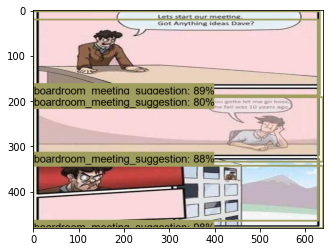

In [31]:
ct=0
for filename in os.listdir(temp):
    if ct>4:
        break
    ct+=1
    if filename.endswith('.jpg'):
        IMAGE_PATH = os.path.join(folder_path, filename)
    img = cv2.imread(IMAGE_PATH)
    image_np = np.array(img)

    input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, 0), dtype=tf.float32)
    detections = detect_fn(input_tensor)

    num_detections = int(detections.pop('num_detections'))
    detections = {key: value[0, :num_detections].numpy()
                  for key, value in detections.items()}
    detections['num_detections'] = num_detections

    # detection_classes should be ints.
    detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

    label_id_offset = 1
    image_np_with_detections = image_np.copy()
    detected+=[detections['detection_classes']]
    viz_utils.visualize_boxes_and_labels_on_image_array(
                image_np_with_detections,
                detections['detection_boxes'],
                detections['detection_classes']+label_id_offset,
                detections['detection_scores'],
                category_index,
                use_normalized_coordinates=True,
                max_boxes_to_draw=5,
                min_score_thresh=.8,
                agnostic_mode=False)

    plt.imshow(cv2.cvtColor(image_np_with_detections, cv2.COLOR_BGR2RGB))
    plt.show()

Detected objects:
	blue_button: 98.97%
	blue_button: 90.60%


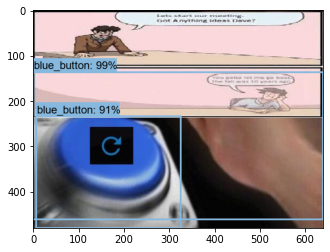

Detected objects:


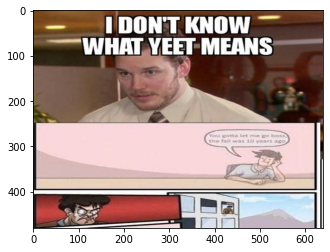

Detected objects:
	boardroom_meeting_suggestion: 98.39%


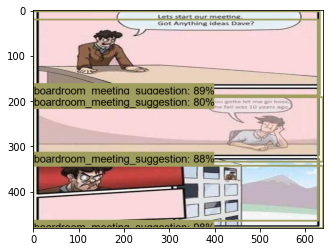

Detected objects:
	afraid_to_ask_andy: 94.79%


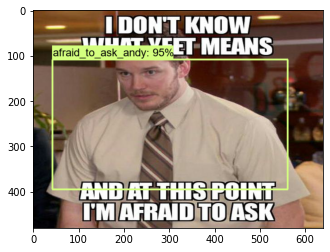

In [84]:
ct = 0
for filename in os.listdir(temp):
    if ct > 4:
        break
    ct += 1
    if filename.endswith('.jpg'):
        IMAGE_PATH = os.path.join(temp, filename)
    img = cv2.imread(IMAGE_PATH)
    image_np = np.array(img)
    input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, 0), dtype=tf.float32)
    detections = detect_fn(input_tensor)

    num_detections = int(detections.pop('num_detections'))
    detections = {key: value[0, :num_detections].numpy()
                  for key, value in detections.items()}
    detections['num_detections'] = num_detections

    # detection_classes should be ints.
    detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

    label_id_offset = 1
    image_np_with_detections = image_np.copy()
    detected = detections['detection_classes']
    detected_names = [category_index[i + label_id_offset]['name'] for i in detected]
    detected_scores = detections['detection_scores']
    print('Detected objects:')
    for i in range(len(detected)):
        if detected_scores[i] > 0.9:
            print('\t{}: {:.2f}%'.format(detected_names[i], detected_scores[i]*100))

    viz_utils.visualize_boxes_and_labels_on_image_array(
        image_np_with_detections,
        detections['detection_boxes'],
        detections['detection_classes'] + label_id_offset,
        detections['detection_scores'],
        category_index,
        use_normalized_coordinates=True,
        max_boxes_to_draw=5,
        min_score_thresh=.8,
        agnostic_mode=False)

    plt.imshow(cv2.cvtColor(image_np_with_detections, cv2.COLOR_BGR2RGB))
    plt.show()


In [74]:
category_index

{1: {'id': 1, 'name': '10_guy'},
 2: {'id': 2, 'name': 'angry_advice_mallard'},
 3: {'id': 3, 'name': 'afraid_to_ask_andy'},
 4: {'id': 4, 'name': 'archer'},
 5: {'id': 5, 'name': 'awkward_moment_sealion'},
 6: {'id': 6, 'name': 'baby_insanity_wolf'},
 7: {'id': 7, 'name': 'bad_luck_brain'},
 8: {'id': 8, 'name': 'birth_control_effectiveness'},
 9: {'id': 9, 'name': 'blue_button'},
 10: {'id': 10, 'name': 'boardroom_meeting_suggestion'},
 11: {'id': 11, 'name': 'but_thats_none_of_my_business'},
 12: {'id': 12, 'name': 'car_salesman'},
 13: {'id': 13, 'name': 'change_my_mind'},
 14: {'id': 14, 'name': 'coma_patient'},
 15: {'id': 15, 'name': 'math_lady'},
 16: {'id': 16, 'name': 'advice_mallard'},
 17: {'id': 17, 'name': 'chopper_argument'},
 18: {'id': 18, 'name': 'dwarf'}}